# EXHEART_16 — NHANES paired-instrument go/no-go probe

**One question, one number.** The whole measurement-aware-fairness extension rests on a single bet:
does the **sex TPR gap shrink under objective measurement relative to self-report, on the *same* people**?
On BRFSS-vs-Cardio that pattern (0.124 → 0.014) is confounded by population, age range, prevalence and
outcome provenance all changing at once. NHANES breaks the confound: the *same* respondents carry both a
self-reported condition and an objectively measured equivalent, so only the measurement instrument changes.

**Design.** On the identical NHANES adults we build two label sets — self-report (BPQ020 / BPQ080 / DIQ010)
and objective (measured BP / total cholesterol / HbA1c) — train the EXHEART stack (XGB + LGBM + RF + MLP →
OOF logistic meta) **twice**, once per label set, on a shared train/test split, and read the sex TPR gap under
each. Fairness is evaluated at a **matched overall sensitivity** (not a fixed probability threshold), so the
gap is ranking-based and immune to the Platt-calibration divergence that affected EXHEART_15. Calibration and
conformal coverage are deferred to the full study; this probe only needs the ranking.

**Decision rule (read the last cell):**
- **GO** — objective gap materially smaller than self-report gap on the same people, and the paired change CI
  excludes 0. The instrument effect is real and confound-free; build the full method (DIF, SIMEX, E-values,
  conformal-by-instrument).
- **SOFT** — point estimate in the right direction but change CI includes 0. Underpowered; consider the
  2017-2018 auscultatory-BP cycle or a larger composite before committing.
- **NO-GO** — gaps within bootstrap noise, or the wrong sign. Stop; ship EXHEART as it stands.

Nothing downstream gets built until this clears.


## 1. Bootstrap (Drive, git identity, deps)

In [4]:
# === EXHEART_16 bootstrap : restores git identity from Drive root, clones/updates repo, adds src/ to path ===
import os, sys, subprocess
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/EXHEART_Research'
REPO_DIR   = os.path.join(DRIVE_ROOT, 'exheart-research')

# restore git config + credentials saved in Drive root (prevents 'Author identity unknown' / 'could not read Username')
for fn in ['.gitconfig', '.git-credentials']:
    src = os.path.join(DRIVE_ROOT, fn)
    if os.path.exists(src):
        subprocess.run(['cp', src, os.path.join('/root', fn)])

os.makedirs(DRIVE_ROOT, exist_ok=True)
if not os.path.isdir(os.path.join(REPO_DIR, '.git')):
    subprocess.run(['git', 'clone', 'https://github.com/anasbiswas1/exheart-research.git', REPO_DIR])

%cd {REPO_DIR}
SRC = os.path.join(REPO_DIR, 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'xgboost', 'lightgbm', 'scikit-learn', 'pandas', 'numpy', 'matplotlib'])
print('bootstrap done | cwd =', os.getcwd())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/EXHEART_Research/exheart-research
bootstrap done | cwd = /content/drive/MyDrive/EXHEART_Research/exheart-research


## 2. Config (paths, NHANES files, thresholds, operating point)

In [5]:
import numpy as np, os
SEED = 42
np.random.seed(SEED)

NB_TAG   = 'EXHEART_16'
OUT_DIR  = os.path.join(REPO_DIR, 'results', 'nhanes_instrument_probe')
TAB_DIR  = os.path.join(OUT_DIR, 'tables')
FIG_DIR  = os.path.join(OUT_DIR, 'figures')
DATA_DIR = os.path.join(REPO_DIR, 'data', 'nhanes')
for d in (TAB_DIR, FIG_DIR, DATA_DIR):
    os.makedirs(d, exist_ok=True)

# --- NHANES pre-pandemic pooled 2017-March 2020 files (P_ prefix). ---
# If the primary base 404s the loader tries the alternate, then falls back to manual files in DATA_DIR.
NHANES_BASE     = 'https://wwwn.cdc.gov/Nchs/Nhanes/2017-2020'
NHANES_BASE_ALT = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles'
NHANES_FILES = {
    'DEMO':'P_DEMO.XPT', 'BPQ':'P_BPQ.XPT', 'BPXO':'P_BPXO.XPT',
    'TCHOL':'P_TCHOL.XPT', 'GHB':'P_GHB.XPT', 'DIQ':'P_DIQ.XPT',
    'BMX':'P_BMX.XPT', 'SMQ':'P_SMQ.XPT',
}

# --- objective thresholds (edit here) ---
HTN_SBP, HTN_DBP = 130, 80     # ACC/AHA 2017; set 140/90 for JNC7
TC_HIGH          = 240         # mg/dL, 'high' total cholesterol
HBA1C_DM         = 6.5         # %

ADULT_MIN_AGE      = 18
TARGET_SENSITIVITY = 0.70      # matched overall sensitivity at which the sex gap is read
BOOT               = 1000
USE_MLP            = True      # False = fast first pass (XGB+LGBM+RF only)

# features: demographics + behaviour + anthropometry ONLY.
# deliberately EXCLUDES measured BP / lipids / HbA1c and their self-reports, which define the labels.
FEATURES = ['AGE', 'SEX', 'BMI', 'SMOKER', 'PIR', 'RACE']
print('config set | target sensitivity =', TARGET_SENSITIVITY, '| MLP =', USE_MLP)


config set | target sensitivity = 0.7 | MLP = True


## 3. Download + merge NHANES on SEQN

In [6]:
import pandas as pd, urllib.request

UA = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                     '(KHTML, like Gecko) Chrome/124.0 Safari/537.36'}

def _is_xport(path):
    try:
        with open(path, 'rb') as f:
            return b'HEADER RECORD' in f.read(80)      # XPORT files begin with this; HTML pages do not
    except Exception:
        return False

def _candidates(fn):
    fl = fn.lower()
    return [f'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/{fn}',
            f'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/{fl}',
            f'https://wwwn.cdc.gov/Nchs/Nhanes/2017-2020/{fn}']

def load_xpt(key):
    fn = NHANES_FILES[key]; local = os.path.join(DATA_DIR, fn)
    if os.path.exists(local) and not _is_xport(local):
        os.remove(local)                                  # purge bad (HTML) cached download
    if not os.path.exists(local):
        got = False
        for url in _candidates(fn):
            try:
                req = urllib.request.Request(url, headers=UA)
                with urllib.request.urlopen(req, timeout=120) as r, open(local, 'wb') as out:
                    out.write(r.read())
                if _is_xport(local):
                    print('  ok', key, '->', url); got = True; break
                os.remove(local); print('  not-xport', url)
            except Exception as e:
                print('  miss', url, '->', type(e).__name__)
        if not got:
            raise FileNotFoundError(
                f'Could not fetch a valid XPORT {fn}. Open the {os.path.splitext(fn)[0]} page on '
                f'wwwn.cdc.gov, download the [XPT] data file, drop it into {DATA_DIR}, and re-run.')
    df = pd.read_sas(local, format='xport'); df.columns = [c.upper() for c in df.columns]
    return df

frames = {k: load_xpt(k) for k in NHANES_FILES}
merged = frames['DEMO']
for k in NHANES_FILES:
    if k == 'DEMO':
        continue
    merged = merged.merge(frames[k], on='SEQN', how='left')
print('merged:', merged.shape, '| unique SEQN =', merged['SEQN'].nunique())


  ok DEMO -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DEMO.XPT
  ok BPQ -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPQ.XPT
  ok BPXO -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BPXO.XPT
  ok TCHOL -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_TCHOL.XPT
  ok GHB -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_GHB.XPT
  ok DIQ -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_DIQ.XPT
  ok BMX -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_BMX.XPT
  ok SMQ -> https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/P_SMQ.XPT
merged: (15560, 116) | unique SEQN = 15560


## 4. Build features and the two instrument label sets

In [7]:
df = merged[merged['RIDAGEYR'] >= ADULT_MIN_AGE].copy()

def yn(s):
    # 1=Yes -> 1.0 ; 2=No -> 0.0 ; 7/9/refused/dont-know/missing -> NaN
    out = pd.Series(np.nan, index=s.index)
    out[s == 1] = 1.0
    out[s == 2] = 0.0
    return out

# ---- objective measures (same construct, measured) ----
sbp = df[['BPXOSY1', 'BPXOSY2', 'BPXOSY3']].mean(axis=1)
dbp = df[['BPXODI1', 'BPXODI2', 'BPXODI3']].mean(axis=1)
obj_htn = ((sbp >= HTN_SBP) | (dbp >= HTN_DBP)).astype('float'); obj_htn[sbp.isna() & dbp.isna()] = np.nan
obj_chol = (df['LBXTC'] >= TC_HIGH).astype('float');            obj_chol[df['LBXTC'].isna()] = np.nan
obj_dm   = (df['LBXGH'] >= HBA1C_DM).astype('float');           obj_dm[df['LBXGH'].isna()]  = np.nan

# ---- self-reports (same construct, questionnaire) ----
sr_htn  = yn(df['BPQ020'])
sr_chol = yn(df['BPQ080'])
sr_dm   = yn(df['DIQ010']); sr_dm[df['DIQ010'] == 3] = 0.0   # 3=borderline -> not diagnosed

def any_pos(cols):
    M = pd.concat(cols, axis=1)
    lab = (M.max(axis=1) >= 1).astype('float')
    lab[M.isna().all(axis=1)] = np.nan          # all components missing -> drop
    return lab                                   # any component observed -> missing others treated as 0

obj_comp = any_pos([obj_htn, obj_chol, obj_dm])
sr_comp  = any_pos([sr_htn,  sr_chol,  sr_dm])

# ---- features (disjoint from all labels) ----
df['AGE']    = df['RIDAGEYR']
df['SEX']    = (df['RIAGENDR'] == 1).astype(int)     # 1 = male, 0 = female
df['BMI']    = df['BMXBMI']
df['SMOKER'] = yn(df['SMQ020'])                      # smoked >=100 cigarettes in life
df['PIR']    = df['INDFMPIR']                        # income-to-poverty ratio
df['RACE']   = df['RIDRETH3']

targets = {'composite': (sr_comp, obj_comp), 'hypertension': (sr_htn, obj_htn)}

print('adults:', len(df))
for name,(s,o) in targets.items():
    both = (s.notna() & o.notna())
    print(f'  {name:12s} | self-report prev {s[both].mean():.3f} | objective prev {o[both].mean():.3f} '
          f'| paired n {both.sum()}')


adults: 9693
  composite    | self-report prev 0.532 | objective prev 0.486 | paired n 8851
  hypertension | self-report prev 0.372 | objective prev 0.424 | paired n 8013


## 5. The EXHEART stack (inline, self-contained) — OOF base learners → logistic meta

In [8]:
import xgboost as xgb, lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
if USE_MLP:
    import tensorflow as tf
    from tensorflow.keras import layers, callbacks, Model, Input

def build_mlp(d):
    inp = Input(shape=(d,))
    x = layers.Dense(256)(inp); x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(128)(x);   x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x); x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m = Model(inp, out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

def oof_stack(Xtr, ytr, Xte):
    # 5-fold OOF for each base learner, logistic-regression meta; returns ranking scores on Xte
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    learners = ['xgb', 'lgb', 'rf'] + (['mlp'] if USE_MLP else [])
    oof = {k: np.zeros(len(Xtr)) for k in learners}
    tep = {k: np.zeros(len(Xte)) for k in learners}
    spw = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
    for fi, (tr, va) in enumerate(skf.split(Xtr, ytr)):
        Xt, Xv, yt = Xtr[tr], Xtr[va], ytr[tr]
        mx = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, scale_pos_weight=spw,
                               subsample=0.8, colsample_bytree=0.8, eval_metric='auc',
                               random_state=SEED + fi, n_jobs=-1)
        mx.fit(Xt, yt); oof['xgb'][va] = mx.predict_proba(Xv)[:, 1]; tep['xgb'] += mx.predict_proba(Xte)[:, 1] / 5
        ml = lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, class_weight='balanced',
                                subsample=0.8, colsample_bytree=0.8, random_state=SEED + fi, n_jobs=-1, verbose=-1)
        ml.fit(Xt, yt); oof['lgb'][va] = ml.predict_proba(Xv)[:, 1]; tep['lgb'] += ml.predict_proba(Xte)[:, 1] / 5
        mr = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced',
                                    random_state=SEED + fi, n_jobs=-1)
        mr.fit(Xt, yt); oof['rf'][va] = mr.predict_proba(Xv)[:, 1]; tep['rf'] += mr.predict_proba(Xte)[:, 1] / 5
        if USE_MLP:
            es = callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5, restore_best_weights=True)
            mm = build_mlp(Xt.shape[1])
            mm.fit(Xt, yt, validation_data=(Xv, ytr[va]), epochs=100, batch_size=256, callbacks=[es], verbose=0)
            oof['mlp'][va] = mm.predict(Xv, verbose=0).ravel(); tep['mlp'] += mm.predict(Xte, verbose=0).ravel() / 5
    Z   = np.column_stack([oof[k] for k in learners])
    Zte = np.column_stack([tep[k] for k in learners])
    meta = LogisticRegression(class_weight='balanced', max_iter=1000).fit(Z, ytr)
    return meta.predict_proba(Zte)[:, 1]
print('stack defined | learners =', ['xgb','lgb','rf'] + (['mlp'] if USE_MLP else []))


stack defined | learners = ['xgb', 'lgb', 'rf', 'mlp']


## 6. Run the probe per target: same people, two instruments, gap at matched sensitivity

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def sens_threshold(y, p, target):
    pos = np.sort(p[y == 1])
    if len(pos) == 0:
        return np.inf
    k = int(np.floor((1 - target) * len(pos)))
    return pos[min(max(k, 0), len(pos) - 1)]

def tpr(y, p, thr, mask):
    yy, pp = y[mask], p[mask]
    d = (yy == 1).sum()
    return np.nan if d == 0 else float(((pp >= thr) & (yy == 1)).sum() / d)

def run_probe(target_name):
    sr_lab, obj_lab = targets[target_name]
    common = sr_lab.notna() & obj_lab.notna() & df[FEATURES].notna().any(axis=1)
    idx = df.index[common]
    tr_idx, te_idx = train_test_split(idx, test_size=0.30, random_state=SEED,
                                      stratify=df.loc[idx, 'SEX'].values)
    imp = SimpleImputer(strategy='median').fit(df.loc[tr_idx, FEATURES])
    scl = StandardScaler().fit(imp.transform(df.loc[tr_idx, FEATURES]))
    MX  = lambda ix: scl.transform(imp.transform(df.loc[ix, FEATURES]))
    Xtr, Xte = MX(tr_idx), MX(te_idx)
    sex_te = df.loc[te_idx, 'SEX'].values

    res = {}
    for inst, lab in [('self_report', sr_lab), ('objective', obj_lab)]:
        ytr = lab.loc[tr_idx].astype(int).values
        yte = lab.loc[te_idx].astype(int).values
        p   = oof_stack(Xtr, ytr, Xte)
        thr = sens_threshold(yte, p, TARGET_SENSITIVITY)
        res[inst] = dict(auc=roc_auc_score(yte, p), prev=float(yte.mean()), thr=thr,
                         tpr_f=tpr(yte, p, thr, sex_te == 0), tpr_m=tpr(yte, p, thr, sex_te == 1),
                         p=p, y=yte)
        res[inst]['gap'] = res[inst]['tpr_m'] - res[inst]['tpr_f']

    rng = np.random.default_rng(SEED)
    boot = {'self_report': [], 'objective': [], 'change': []}
    n = len(te_idx)
    for _ in range(BOOT):
        bs = rng.integers(0, n, n); row = {}
        for inst in ('self_report', 'objective'):
            r = res[inst]; yb, pb, sb = r['y'][bs], r['p'][bs], sex_te[bs]
            t = sens_threshold(yb, pb, TARGET_SENSITIVITY)
            row[inst] = tpr(yb, pb, t, sb == 1) - tpr(yb, pb, t, sb == 0)
            boot[inst].append(row[inst])
        boot['change'].append(row['objective'] - row['self_report'])
    ci = lambda a: tuple(np.nanpercentile(np.array([x for x in a if np.isfinite(x)]), [2.5, 97.5]))

    out = dict(target=target_name, n_train=len(tr_idx), n_test=n)
    for inst in ('self_report', 'objective'):
        out[inst] = {k: res[inst][k] for k in ('auc', 'prev', 'tpr_f', 'tpr_m', 'gap')}
        out[inst]['ci'] = ci(boot[inst])
    out['change'] = dict(point=res['objective']['gap'] - res['self_report']['gap'], ci=ci(boot['change']))
    return out

results = {}
for t in ['composite', 'hypertension']:
    print(f'\n=== {t} ===')
    r = results[t] = run_probe(t)
    for inst in ('self_report', 'objective'):
        d = r[inst]
        print(f'  {inst:12s} AUC {d["auc"]:.3f} | prev {d["prev"]:.3f} | '
              f'TPR F {d["tpr_f"]:.3f} M {d["tpr_m"]:.3f} | gap {d["gap"]:+.3f} '
              f'[{d["ci"][0]:+.3f}, {d["ci"][1]:+.3f}]')
    c = r['change']
    print(f'  CHANGE (objective - self_report) gap = {c["point"]:+.3f} [{c["ci"][0]:+.3f}, {c["ci"][1]:+.3f}]')



=== composite ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  self_report  AUC 0.824 | prev 0.535 | TPR F 0.691 M 0.710 | gap +0.019 [-0.031, +0.063]
  objective    AUC 0.733 | prev 0.485 | TPR F 0.678 M 0.722 | gap +0.044 [-0.014, +0.093]
  CHANGE (objective - self_report) gap = +0.024 [-0.029, +0.074]

=== hypertension ===


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  self_report  AUC 0.811 | prev 0.370 | TPR F 0.741 M 0.660 | gap -0.081 [-0.142, -0.025]
  objective    AUC 0.710 | prev 0.419 | TPR F 0.704 M 0.697 | gap -0.006 [-0.070, +0.047]
  CHANGE (objective - self_report) gap = +0.075 [+0.001, +0.144]


## 7. Figure + CSV

saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/tables/nhanes_instrument_probe.csv
saved /content/drive/MyDrive/EXHEART_Research/exheart-research/results/nhanes_instrument_probe/figures/nhanes_instrument_probe.png


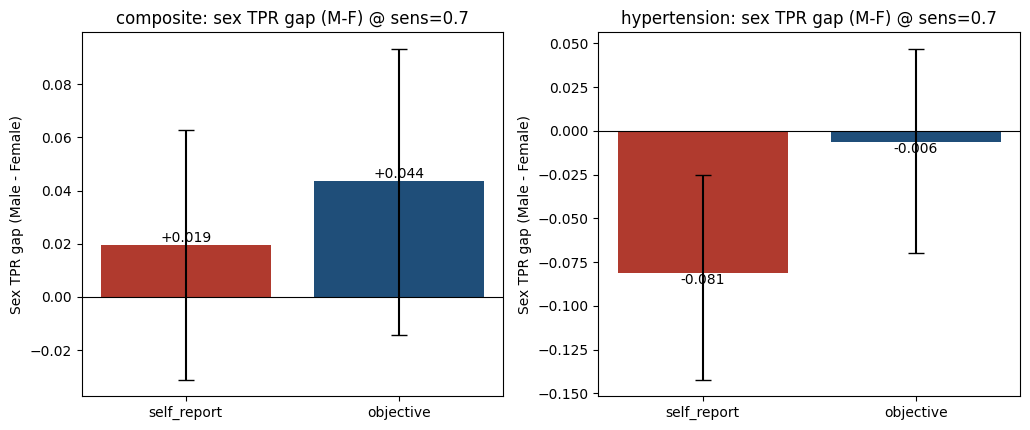

In [10]:
import matplotlib.pyplot as plt, csv

rows = []
for t, r in results.items():
    for inst in ('self_report', 'objective'):
        d = r[inst]
        rows.append(dict(target=t, instrument=inst, auc=round(d['auc'],4), prevalence=round(d['prev'],4),
                         tpr_female=round(d['tpr_f'],4), tpr_male=round(d['tpr_m'],4),
                         sex_gap=round(d['gap'],4), ci_low=round(d['ci'][0],4), ci_high=round(d['ci'][1],4)))
    rows.append(dict(target=t, instrument='CHANGE(obj-sr)', auc='', prevalence='', tpr_female='', tpr_male='',
                     sex_gap=round(r['change']['point'],4), ci_low=round(r['change']['ci'][0],4),
                     ci_high=round(r['change']['ci'][1],4)))

csv_path = os.path.join(TAB_DIR, 'nhanes_instrument_probe.csv')
with open(csv_path, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print('saved', csv_path)

fig, axes = plt.subplots(1, len(results), figsize=(5.2*len(results), 4.4), squeeze=False)
for ax, (t, r) in zip(axes[0], results.items()):
    insts = ['self_report', 'objective']
    gaps  = [r[i]['gap'] for i in insts]
    errs  = [[r[i]['gap']-r[i]['ci'][0] for i in insts], [r[i]['ci'][1]-r[i]['gap'] for i in insts]]
    ax.bar(insts, gaps, yerr=errs, capsize=6, color=['#B03A2E', '#1F4E79'])
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{t}: sex TPR gap (M-F) @ sens={TARGET_SENSITIVITY}')
    ax.set_ylabel('Sex TPR gap (Male - Female)')
    for i, g in enumerate(gaps):
        ax.text(i, g, f'{g:+.3f}', ha='center', va='bottom' if g >= 0 else 'top')
fig.tight_layout()
fig_path = os.path.join(FIG_DIR, 'nhanes_instrument_probe.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight'); print('saved', fig_path); plt.show()


## 8. Verdict — GO / SOFT / NO-GO

In [11]:
def gate(auc_sr, auc_obj):
    return min(auc_sr, auc_obj) >= 0.60

print('='*66)
for t, r in results.items():
    sr, ob, ch = r['self_report'], r['objective'], r['change']
    pt, (lo, hi) = ch['point'], ch['ci']
    shrinks   = pt < 0                 # objective gap smaller than self-report gap
    significant = hi < 0               # paired change CI excludes zero
    reliable  = gate(sr['auc'], ob['auc'])
    verdict = ('GO'   if (shrinks and significant and reliable) else
               'SOFT' if (shrinks and reliable) else
               'NO-GO')
    print(f'[{t}]  self-report gap {sr["gap"]:+.3f}  ->  objective gap {ob["gap"]:+.3f}   '
          f'change {pt:+.3f} [{lo:+.3f}, {hi:+.3f}]')
    print(f'       model AUCs {sr["auc"]:.3f}/{ob["auc"]:.3f} (reliable={reliable})  =>  **{verdict}**')
    print('-'*66)

print('Read: GO on the composite (or hypertension) means the sex gap is instrument-dependent on a '
      'confound-free population -> build the full method. SOFT = right direction but underpowered '
      '(try the 2017-2018 auscultatory-BP cycle or widen the composite). NO-GO on both = stop and '
      'submit EXHEART as it stands.')


[composite]  self-report gap +0.019  ->  objective gap +0.044   change +0.024 [-0.029, +0.074]
       model AUCs 0.824/0.733 (reliable=True)  =>  **NO-GO**
------------------------------------------------------------------
[hypertension]  self-report gap -0.081  ->  objective gap -0.006   change +0.075 [+0.001, +0.144]
       model AUCs 0.811/0.710 (reliable=True)  =>  **NO-GO**
------------------------------------------------------------------
Read: GO on the composite (or hypertension) means the sex gap is instrument-dependent on a confound-free population -> build the full method. SOFT = right direction but underpowered (try the 2017-2018 auscultatory-BP cycle or widen the composite). NO-GO on both = stop and submit EXHEART as it stands.


## 9. Save + commit + push

In [ ]:
%cd {REPO_DIR}
!git add -A
!git -c user.name="Md Anas Biswas" -c user.email="anasbiswas@gmail.com" commit -m "EXHEART_16: NHANES paired-instrument go/no-go probe (self-report vs objective sex TPR-gap, same population, matched-sensitivity)"
!git push origin main
print('committed + pushed. Save this notebook to notebooks/EXHEART_16_nhanes_instrument_probe.ipynb via the Drive UI before closing.')


/content/drive/MyDrive/EXHEART_Research/exheart-research
